In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv(
    "../data/processed/featured_uhi.csv"
)

df.head()

,LST,Latitude,Longitude,NDBI,NDVI,Green_Built_Ratio,Heat_Exposure_Index
0,43.919170,19.970832,75.438700,0.127207,0.162286,1.182783,5.586821
1,39.060455,19.729093,75.209548,-0.272423,0.570751,2.020910,-10.640952
2,40.231127,19.788775,75.225639,0.055877,0.099371,1.508423,2.248012
3,44.884761,19.960297,75.544582,0.121404,0.196037,1.491866,5.449194
4,48.502735,19.867709,75.486062,0.133151,0.165262,1.154459,6.458205


In [3]:
X = df[
    [
        "NDVI",
        "NDBI",
        "Latitude",
        "Longitude",
        "Green_Built_Ratio",
        "Heat_Exposure_Index"
    ]
]

y = df["LST"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Trained")

Random Forest Trained


In [6]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
5,Heat_Exposure_Index,0.504028
1,NDBI,0.165245
4,Green_Built_Ratio,0.103112
3,Longitude,0.092648
0,NDVI,0.073757
2,Latitude,0.061211


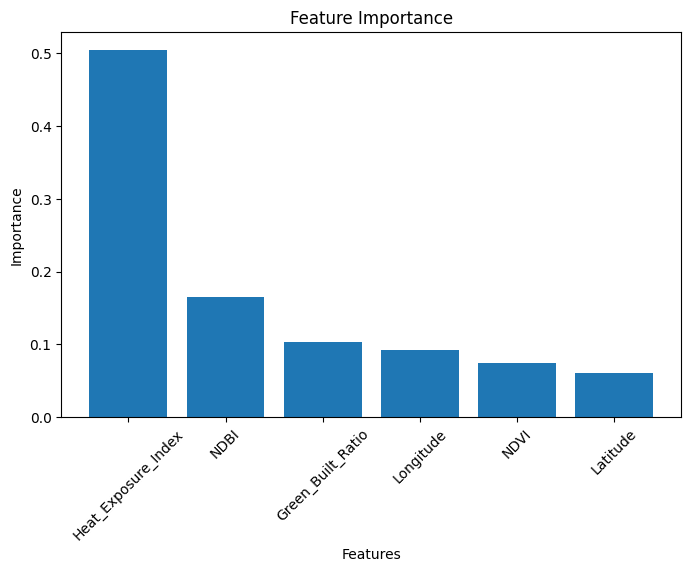

In [7]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [8]:
feature_importance

,Feature,Importance
5,Heat_Exposure_Index,0.504028
1,NDBI,0.165245
4,Green_Built_Ratio,0.103112
3,Longitude,0.092648
0,NDVI,0.073757
2,Latitude,0.061211
